In [1]:
# Base Imports
import os,sys
import numpy as np
import matplotlib.pyplot as plt
import scipy

#Skyllh Imports
from skyllh.core.config import Config
from skyllh.datasets.i3.PublicData_10y_ps import create_dataset_collection
# For power law source model
from skyllh.analyses.i3.publicdata_ps.time_integrated_ps import create_analysis as create_analysis_with_simple_pl
# For custom source model
from skyllh.analyses.i3.publicdata_ps.time_integrated_ps_function_energy_spectrum  import create_analysis as create_analysis_with_custom_mdl

from skyllh.core.source_model import PointLikeSource
from skyllh.core.random import RandomStateService
from skyllh.core.utils.analysis import create_trial_data_file
from skyllh.core.timing import TimeLord
from skyllh.core.utils.analysis import extend_trial_data_file

import matplotlib as mpl
font = {'size'   : 25}
mpl.rc('font', **font) 

In [2]:
import skyllh

In [3]:
skyllh.__version__ #The github one givs some value like 0+untagged.2372.g6704ef9

'0+untagged.2396.g38d1b99.dirty'

In [4]:
os.getcwd()

'/Users/aadesai1/Desktop/In_use/public_IceCube_data/justin_paper_checks'

In [6]:
sources = [["Tycho",6.3208,64.15],       #0, dec +64° 09’
           ["CassA",350.9,58.81],       #1, dec +58° 48’ 41”
           ["IC443",94.3,22.52],       #2, dec +22° 31’ 05”
           ["RX_J1713",17.23,- 39.77],  #3, dec -39° 46’
           ["SN1006",225.7,- 41.95]]    #4, dec -41° 57’

# Default = Tycho
test_source = 0
source_tested = sources[test_source]

# Optional Parameters for possible tests:
kde_used=False 
#kde_used=True
source_mdl_used = "PL"
#source_mdl_used = "custom" 
#minimizer_used='minuit'
minimizer_used='LBFGS'

In [7]:
# Make possible directories
if os.path.isdir(f'Image_plots')!=True:
    os.mkdir(f'Image_plots')
if os.path.isdir(f'Data_files')!=True:
    os.mkdir(f'Data_files')
if os.path.isdir(f'Cache')!=True:
    os.mkdir(f'Cache')

Create a configuration

In [8]:
help(Config)

Help on class Config in module skyllh.core.config:

class Config(builtins.dict)
 |  Config() -> None
 |  
 |  This class, derived from dict, holds the a local configuration state.
 |  
 |  Method resolution order:
 |      Config
 |      builtins.dict
 |      builtins.object
 |  
 |  Methods defined here:
 |  
 |  __init__(self) -> None
 |      Initializes a new Config instance holding the base configuration.
 |  
 |  disable_tracing(self)
 |      Disables the tracing mode of SkyLLH.
 |      
 |      Returns
 |      -------
 |      self : instance of Config
 |          The updated instance of Config.
 |  
 |  enable_tracing(self)
 |      Enables the tracing mode of SkyLLH.
 |      
 |      Returns
 |      -------
 |      self : instance of Config
 |          The updated instance of Config.
 |  
 |  get_wd(self)
 |      Retrieves the absolute path to the working directory as configured in
 |      this configuration.
 |      
 |      Returns
 |      -------
 |      wd : str
 |          Th

In [9]:
cfg = Config()
cfg.set_ncpu(16)
cfg

{'multiproc': {'ncpu': 16},
 'debugging': {'log_format': '%(asctime)s %(processName)s %(name)s %(levelname)s: %(message)s',
  'enable_tracing': False},
 'project': {'working_directory': '.'},
 'repository': {'base_path': None, 'download_from_origin': True},
 'units': {'internal': {'angle': Unit("rad"),
   'energy': Unit("GeV"),
   'length': Unit("cm"),
   'time': Unit("s")},
  'defaults': {'fluxes': {'angle': Unit("rad"),
    'energy': Unit("GeV"),
    'length': Unit("cm"),
    'time': Unit("s")}}},
 'datafields': {'run': 4,
  'ra': 4,
  'dec': 4,
  'ang_err': 4,
  'time': 4,
  'log_energy': 4,
  'true_ra': 8,
  'true_dec': 8,
  'true_energy': 8,
  'mcweight': 8},
 'caching': {'pdf': {'MultiDimGridPDF': False}}}

Load the public Dataset

In [10]:
dsc = create_dataset_collection(
    cfg=cfg,
    base_path='/Users/aadesai1/Desktop/In_use/public_IceCube_data/10yr_public_pstracks')

In [11]:
#Checking data
dsc.dataset_names

['IC40',
 'IC59',
 'IC79',
 'IC86_I',
 'IC86_II',
 'IC86_II-VII',
 'IC86_III',
 'IC86_IV',
 'IC86_V',
 'IC86_VI',
 'IC86_VII']

In [12]:
datasets = dsc['IC40', 'IC59', 'IC79', 'IC86_I', 'IC86_II-VII']

In [13]:
# To check parameters for create_analysis
# help(create_analysis)
name_used= source_tested[0]
ra_used = source_tested[1]
dec_used = source_tested[2]

source = PointLikeSource(name=name_used,ra=np.deg2rad(ra_used), dec=np.deg2rad(dec_used))

In [14]:
source_tested

['Tycho', 6.3208, 64.15]

In [15]:
print("Energy Model: ",source_mdl_used)
if source_mdl_used=="PL":
    print("Simple Power Law Used")
    E_refrence_val =1000.0
    spectral_index =2.0
    
else:
    print("Custom Model Used")
    print("Setup to be updated in future version")


Energy Model:  PL
Simple Power Law Used


In [16]:
create_analysis = create_analysis_with_simple_pl
#help(create_analysis) # To see details of setup!

In [17]:
if source_mdl_used=="PL":
    ana = create_analysis_with_simple_pl(cfg=cfg, 
                      datasets=datasets, 
                      source=source,
                      refplflux_Phi0=1,             #Flux normalization for model
                      refplflux_E0=E_refrence_val,          # E_0
                      refplflux_gamma=spectral_index,          # spectral index
                      ns_seed=100.0,                # Initial seed
                      ns_min=0.0, 
                      ns_max=1000.0, 
                      gamma_seed=3.0,               # Initial seed
                      gamma_min=1.0,  
                      gamma_max=5.0, 
                      kde_smoothing=kde_used,           # KDE!
                      minimizer_impl=minimizer_used,        # LBFGS or minuit
                      cut_sindec=None,               # energy cut?
                      spl_smooth=None,               # Smoothing parameters for the 1D spline for the energy cut
                      cap_ratio=False,               # energy PDF ratio will be capped if True
                                                     # If kde_smoothing is set to True, cap_ratio should be set to False!
                      compress_data=True,            
                      keep_data_fields=None,         # additional data field names that should get kept
                      evt_sel_delta_angle_deg=10,    # angle in degrees for the event selection optimization
                      construct_sig_generator=True,
                      tl=None,                       # TimeLord instance to use to time
                      ppbar=None,                    # ProgressBar 
                      logger_name=None)
else:
    print("Custom Model Used")
    print("Setup to be updated in future version")


100%|██████████████████████████████████████████| 220/220 [00:02<00:00, 104.83it/s]


In [18]:
# Just to check for custom model:
#ana.shg_mgr.get_fluxmodel_by_src_idx(0).energy_profile(E=10**6).squeeze()*10**6*10**6


In [19]:
#np.log10(eng_interst[np.argmax(nu_flux_val)])

# Calculating the sensitivity


### First Generate Background Trials

In [20]:
trials_directory = f'Cache/{name_used}_trials/'
if os.path.isdir(trials_directory)!= True:
    os.mkdir(trials_directory)
bkg_pathfilename = f'{trials_directory}/bkg_trials.npy'
tl = TimeLord()
rss = RandomStateService(seed=1)

if os.path.isfile(bkg_pathfilename)!=True:
    trials_data = create_trial_data_file(ana=ana,
                                     rss=rss,
                                     n_trials=1e4,
                                     mean_n_sig=0,
                                     pathfilename=bkg_pathfilename,
                                     ncpu=8,
                                     tl=tl)
else:
    trials = np.load(bkg_pathfilename)
while len(trials['ns'])<1e5:
    print(len(trials['ns']))
    trials = extend_trial_data_file(ana=ana,
                                rss=rss,
                                n_trials=1e4,
                                trial_data=trials,
                                pathfilename=bkg_pathfilename,
                                ncpu=8,
                                tl=tl)
    trials = np.load(bkg_pathfilename)
    print("Final:",len(trials['ns']),"\n\n")



In [21]:
num_trials = len(trials['ns'])

In [22]:
bkg_ts=trials['ts']
bkg_ns=trials['ns']
bkg_mean_n_sig=trials['mean_n_sig']
bkg_gamma=trials['gamma']


In [23]:
import histlite as hl

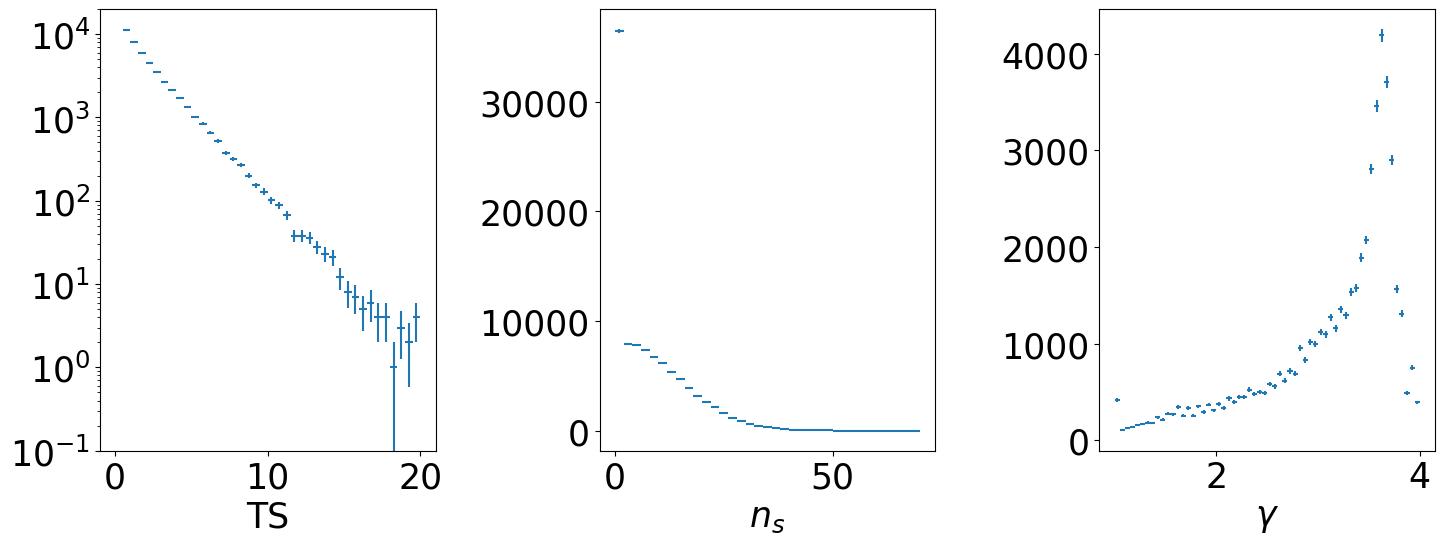

In [24]:

fig, axs = plt.subplots(1, 3, figsize=(15,6))

if source_mdl_used=="PL":
    h_gamma = hl.hist(bkg_gamma[bkg_ns > 0], bins=np.r_[1:4.01:.05])
else:
    h_epeak = hl.hist(bkg_epeak[bkg_ns > 0], bins=np.r_[3:10.01:.1])

h_ts = hl.hist(bkg_ts, bins=np.r_[:20.1:.5])
h_ns = hl.hist(bkg_ns, bins=np.r_[:70.1:2])

hl.plot1d(axs[0], h_ts, crosses=True)
hl.plot1d(axs[1], h_ns, crosses=True)
if source_mdl_used=="PL":
    hl.plot1d(axs[2], h_gamma, crosses=True)
    axs[2].set_xlabel(r'$\gamma$')
else:
    hl.plot1d(axs[2], h_epeak, crosses=True)
    axs[2].set_xlabel(r'E$_{peak}$')

axs[0].set_xlabel("TS")
axs[1].set_xlabel(r'$n_s$')



axs[0].set_ylim(1e-1, 2e4)
axs[0].semilogy()
#axs[1].semilogy()
plt.tight_layout()
if kde_used==True:
    plt.savefig(f'bkg_TS_ns_g_dist_{num_trials}_trials_sig_with_kde.png')
else:
    plt.savefig(f'bkg_TS_ns_g_dist_{num_trials}_trials_sig_no_kde.png')


### Next calculate sensitivity

In [25]:
from skyllh.core.utils.analysis import estimate_sensitivity,estimate_discovery_potential 

rss = RandomStateService(seed=2)

In [29]:
energy_bins = np.logspace(2.5,6,6) #Energy bins in GeV

sens_values = []
dp_values = []

for i in range(len(energy_bins)):
    if i==0:
        continue
    emin_used = energy_bins[i-1]
    emax_used = energy_bins[i]
    sig_kwargs = {'energy_range': (emin_used,emax_used)}
    
    sens = estimate_sensitivity(ana=ana,
                            rss=rss,
                            h0_trials=trials,
                            mu_range=(1,100),
                            sig_kwargs=sig_kwargs,
                            h0_ts_quantile=0.5,
                            p=0.9,
                            pathfilename = f'{trials_directory}/sens_sig_trials_{emin_used}_{emax_used}.npy')
    sens_values.append(sens)
    
    dp_5sig = estimate_discovery_potential(ana=ana,
                            rss=rss,
                            h0_trials=trials,
                            mu_range=(1,100),
                            sig_kwargs=sig_kwargs,
                            h0_ts_quantile=2.8665e-7, 
                            p=0.5,
                            pathfilename = f'{trials_directory}/sig_trials_{emin_used}_{emax_used}.npy')
    dp_values.append(dp_5sig)
    print(sens)
    print(dp_5sig)

100%|██████████████████████████████████| 10000/10000 [01:37<00:00, 102.07it/s]


(9.562403674611572, None)
(27.32016922375857, None)


100%|███████████████████████████████████| 10000/10000 [01:40<00:00, 99.40it/s]


(9.437354006618179, None)
(27.497211704374195, None)


 18%|█████▉                           | 71471/400001 [07:38<36:47, 148.80it/s]Process Process-1602:
Process Process-1594:
Process Process-1596:
Process Process-1603:
Process Process-1597:
Process Process-1599:
Process Process-1592:
Process Process-1593:
Process Process-1598:
Process Process-1595:
Process Process-1604:
Process Process-1601:
Process Process-1605:
Traceback (most recent call last):
Traceback (most recent call last):
Traceback (most recent call last):
Traceback (most recent call last):
  File "/Users/aadesai1/miniforge3/lib/python3.10/multiprocessing/process.py", line 314, in _bootstrap
    self.run()
Traceback (most recent call last):
Traceback (most recent call last):
Process Process-1600:
Traceback (most recent call last):
Traceback (most recent call last):
Traceback (most recent call last):
Traceback (most recent call last):
Traceback (most recent call last):
Traceback (most recent call last):
  File "/Users/aadesai1/miniforge3/lib/python3.10/multiprocessing/process.py

### Initializing a trial

After the Analysis instance was created trials can be run. To do so the analysis needs to be initialized with some trial data. For instance we could initialize the analysis with the experimental data to “unblind” the analysis afterwards. Technically the TrialDataManager of each log-likelihood ratio function, i.e. dataset, is initialized with data.

The Analysis class provides the method initialize_trial to initialize a trial with data. It takes a list of DataFieldRecordArray instances holding the events. If we want to initialize a trial with the experimental data, we can get that list from the Analysis instance itself:

In [32]:
events_list = [ data.exp for data in ana.data_list ]
ana.initialize_trial(events_list)

### Maximizing the log-likelihood ratio function

After initializing a trial, we can maximize the LLH ratio function using the maximize_llhratio method of the Analysis class. This method requires a RandomStateService instance in case the minimizer does not succeed and a new set of initial values for the fit parameters need to get generated. The method returns a 4-element tuple. The first element is the set of fit parameters used in the maximization. The second element is the value of the LLH ration function at its maximum. The third element is the array of the fit parameter values at the maximum, and the forth element is the status dictionary of the minimizer.

In [33]:
from skyllh.core.random import RandomStateService
rss = RandomStateService(seed=10)

In [34]:
(log_lambda_max, fitparam_values, status) = ana.llhratio.maximize(rss)

In [35]:
print(f'log_lambda_max = {log_lambda_max}')
print(f'fitparam_values = {fitparam_values}')
print(f'status = {status}')

log_lambda_max = 1.198277705144604
fitparam_values = [18.66828574  4.84527999]
status = {'grad': array([ 1.76697727e-06, -1.45158782e-07]), 'task': 'CONVERGENCE: NORM_OF_PROJECTED_GRADIENT_<=_PGTOL', 'funcalls': 23, 'nit': 17, 'warnflag': 0, 'skyllh_minimizer_n_reps': 0, 'n_llhratio_func_calls': 23}


In [36]:
TS = ana.calculate_test_statistic(log_lambda_max, fitparam_values)
print(f'TS = {TS:.3f}')

TS = 2.397


### Unblinding the data and Getting Best Fit Values!

After creating the analysis instance we can unblind the data for the choosen source. Hence, we initialize the analysis with a trial of the experimental data, maximize the log-likelihood ratio function for all given experimental data events, and calculate the test-statistic value. The analysis instance has the method unblind that can be used for that. 

In [37]:
rss = RandomStateService(seed=1)

In [38]:
#help(ana.unblind)

In [39]:
(ts, x, status) = ana.unblind(minimizer_rss=rss)
print(ts, x, status)

2.396555410289208 {'ns': 18.668285742858266, 'gamma': 4.845279994267476} {'grad': array([ 1.76697727e-06, -1.45158782e-07]), 'task': 'CONVERGENCE: NORM_OF_PROJECTED_GRADIENT_<=_PGTOL', 'funcalls': 23, 'nit': 17, 'warnflag': 0, 'skyllh_minimizer_n_reps': 0, 'n_llhratio_func_calls': 23}


In [40]:
print(f'TS = {ts:.3f}')
print(f'ns = {x["ns"]:.2f}')
if source_mdl_used=="PL":
    print(f'gamma = {x["gamma"]:.2f}')
else:
    print(f'e_peak = {x["e_peak"]:.2f}')
    

TS = 2.397
ns = 18.67
gamma = 4.85


In [41]:
x

{'ns': 18.668285742858266, 'gamma': 4.845279994267476}

In [42]:
scipy.stats.chi2.ppf(0.68, df=2)

2.27886856637673

In [43]:
minus_log10_pval = -np.log10(len(trials[trials['ts'] > ts]) / len(trials))
print(f'-log10(p_local) = {minus_log10_pval:.2f}')



-log10(p_local) = 0.76


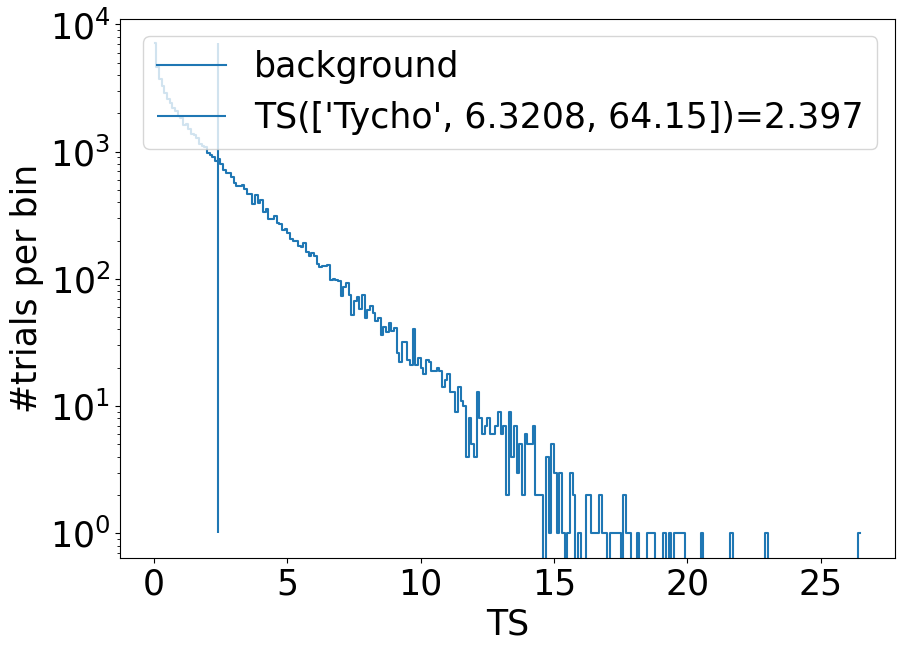

In [44]:
plt.figure(figsize=(10,7))
(h, be) = np.histogram(trials['ts'], bins=np.arange(0, np.max(trials['ts'])+0.1, 0.1))
plt.plot(0.5*(be[:-1]+be[1:]), h, drawstyle='steps-mid', label='background')
plt.vlines(ts, 1, np.max(h), label=f'TS({source_tested})={ts:.3f}')
plt.yscale('log')
plt.xlabel('TS')
plt.ylabel('#trials per bin')
plt.legend()
if kde_used==True:
    plt.savefig(f'bkg_TS_dist_{num_trials}_trials__with_kde.png')
else:
    plt.savefig(f'bkg_TS_dist_{num_trials}_trials_sig_no_kde.png')

# Calculating the corresponding flux normalization

By default the analysis is created with a flux normalization of 1 GeV-1s-1cm-2sr-1 
(see refplflux_Phi0 argument of the create_analysis method). 
The analysis instance has the method calculate_fluxmodel_scaling_factor that 
calculates the scaling factor the reference flux normalization has to be 
multiplied with to represent a given analysis result, i.e. and  value. 
This function takes the detected mean  value as first argument and the list of source parameter values as second argument:

In [45]:
if source_mdl_used=="PL":
    scaling_factor = ana.calculate_fluxmodel_scaling_factor(x['ns'], [x['ns'], x['gamma']])
else:
    print("To be updated")
print(f'Flux scaling factor = {scaling_factor:.3e}')

Flux scaling factor = 1.320e-15


In [46]:
if source_mdl_used!="PL":
    ana.calculate_fluxmodel_scaling_factor(2, [2000, x['e_peak']])

In [47]:
if source_mdl_used!="PL":
    ana.shg_mgr.get_fluxmodel_by_src_idx(0).energy_profile(E=10**x['e_peak']).squeeze()

In [48]:
if source_mdl_used=="PL":
    print(f'{scaling_factor:.3e}'' (E/1000 GeV)^{-'f'{x["gamma"]:.2f}'+'} 1/(GeV s cm^2 sr)')
    err_lo = ana.calculate_fluxmodel_scaling_factor(x['ns']-15, [x['ns'], x['gamma']])
    err_hi = ana.calculate_fluxmodel_scaling_factor(x['ns']+15, [x['ns'], x['gamma']])
    print(f'{scaling_factor:.3e}+{err_lo:.3e}-{err_hi:.3e} ''(E/1000 GeV)^{-'f'{x["gamma"]:.2f}'+'} 1/(GeV s cm^2 sr)')

else:
    print("To be updated")
    



1.320e-15 (E/1000 GeV)^{-4.85} 1/(GeV s cm^2 sr)
1.320e-15+2.594e-16-2.381e-15 (E/1000 GeV)^{-4.85} 1/(GeV s cm^2 sr)


### Evaluating the log-likelihood ratio function
Sometimes it is useful to be able to evaluate the log-likelihood ratio function, e.g. for creating a likelihood contour plot. Because SkyLLH’s structure is based on the mathematical structure of the likelihood function, the Analysis instance has the property llhratio which is the class instance of the used log-likelihood ratio function. This instance has the method evaluate. The method takes an array of the fit parameter values as argument at which the LLH ratio function will be evaluated. It returns the value of the LLH ratio function at the given point and its gradients w.r.t. the fit parameters.

In our case this is the number of signal events, 
 and the spectral index 
. If we evaluate the LLH ratio function at the maximum, the gradients should be close to zero.



In [49]:
help(ana.llhratio.evaluate)

Help on method evaluate in module skyllh.core.llhratio:

evaluate(fitparam_values, src_params_recarray=None, tl=None) method of skyllh.core.llhratio.MultiDatasetTCLLHRatio instance
    Evaluates the composite log-likelihood-ratio function and returns its
    value and global fit parameter gradients.
    
    Parameters
    ----------
    fitparam_values : instance of numpy ndarray
        The (N_fitparams,)-shaped numpy 1D ndarray holding the current
        values of the global fit parameters.
    src_params_recarray : instance of numpy record ndarray | None
        The numpy record ndarray of length N_sources holding the parameter
        names and values of all sources.
        See the documentation of the
        :meth:`skyllh.core.parameters.ParameterModelMapper.create_src_params_recarray`
        method for more information about this array.
        It case it is ``None``, it will be created automatically from the
        ``fitparam_values`` argument using the
        :class:`~sk

In [50]:

if source_mdl_used=="PL":
    (llhratio_value, (grad_ns, grad_gamma)) = ana.llhratio.evaluate([14.58, 2.17])
    print(f'llhratio_value = {llhratio_value:.3f}')
    print(f'grad_ns = {grad_ns:.3f}')
    print(f'grad_gamma = {grad_gamma:.3f}')
else:
    print("To be updated")

llhratio_value = -0.441
grad_ns = -0.092
grad_gamma = 2.299


In [52]:
fitparam_values

array([18.66828574,  4.84527999])

Using the evaluate method of the LLHRatio class we can scan the log-likelihood ratio space and create a contour plot showing the best fit and the 68%, 90%, and 95% quantile assuming Wilks-theorem.



In [53]:
source_mdl_used

'PL'

In [55]:

(ns_min, ns_max, ns_step) = (1, 80, 0.5)
#(ns_min, ns_max, ns_step) = (1, 180, 1.0)
if source_mdl_used=="PL":
    (gamma_min, gamma_max, gamma_step) = (1.5, 4.0, 0.1)
else: 
    print("To be updated")    

ns_edges = np.linspace(ns_min, ns_max, int((ns_max-ns_min)/ns_step)+1)
ns_vals = 0.5*(ns_edges[1:] + ns_edges[:-1])

if source_mdl_used=="PL":
    gamma_edges = np.linspace(gamma_min, gamma_max, int((gamma_max-gamma_min)/gamma_step+1))
    gamma_vals = 0.5*(gamma_edges[1:] + gamma_edges[:-1])
    delta_ts = np.empty((len(ns_vals), len(gamma_vals)), dtype=np.double)
    for (ns_i, ns) in enumerate(ns_vals):
        for (gamma_i, gamma) in enumerate(gamma_vals):
            delta_ts[ns_i, gamma_i] = (
                ana.calculate_test_statistic(llhratio_value, fitparam_values) -
                ana.calculate_test_statistic(ana.llhratio.evaluate([ns, gamma])[0], [ns, gamma])
                )
    # Determine the best fit ns and gamma values from the scan.
    index_max = np.argmin(delta_ts)
    ns_i_max = int(index_max / len(gamma_vals))
    gamma_i_max = index_max % len(gamma_vals)
    ns_best = ns_vals[ns_i_max]
    gamma_best = gamma_vals[gamma_i_max]
else:
    print("To be updated")



In [58]:
# Determine the delta lambda value for the 95% quantile assuming a chi-sqaure
# distribution with 2 degrees of freedom (i.e. assuming Wilks theorem).
if source_mdl_used=="PL":
    df_used = 2
else:
    df_used = 1
chi2_68_quantile = scipy.stats.chi2.ppf(0.68, df=df_used)
chi2_90_quantile = scipy.stats.chi2.ppf(0.90, df=df_used)
chi2_95_quantile = scipy.stats.chi2.ppf(0.95, df=df_used)

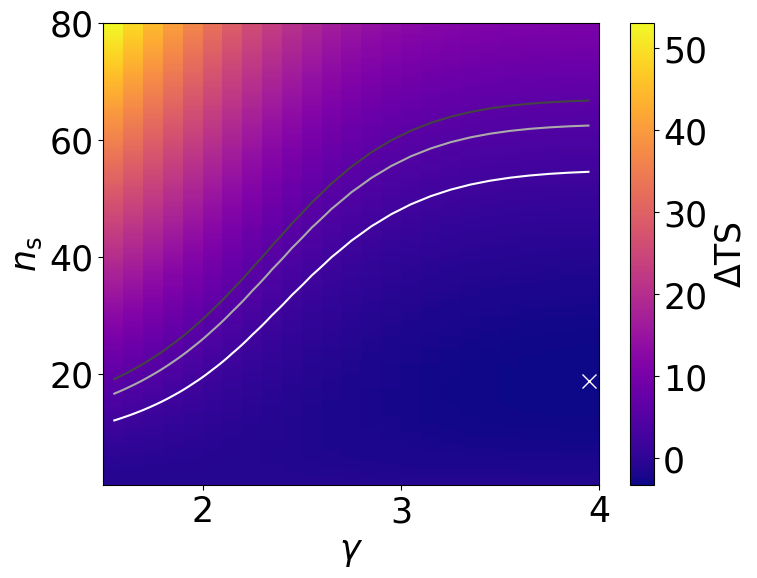

In [59]:

from matplotlib.colors import LogNorm
if source_mdl_used=="PL":
    plt.figure(figsize=(8,6))
    plt.pcolormesh(gamma_edges, ns_edges, delta_ts, cmap='plasma')
    cbar = plt.colorbar()
    cbar.set_label(r'$\Delta$TS')
    plt.contour(gamma_vals, ns_vals, delta_ts, [chi2_68_quantile], colors='#FFFFFF')
    plt.contour(gamma_vals, ns_vals, delta_ts, [chi2_90_quantile], colors='#AAAAAA')
    plt.contour(gamma_vals, ns_vals, delta_ts, [chi2_95_quantile], colors='#444444')
    plt.plot(gamma_best, ns_best, marker='x', color='white', ms=10)
    plt.xlabel(r'$\gamma$')
    plt.ylabel(r'$n_{\mathrm{s}}$')
    plt.ylim(ns_min, ns_max)
    plt.xlim(gamma_min, gamma_max)

    if kde_used==True:
        plt.savefig(f'ns_gamma_likelihood_with_kde.png')
    else:
        plt.savefig(f'ns_gamma_likelihood_no_kde.png')
else:
    print("To be updated")